# analyzing fluorescence response re sound intensity across animals

In [3]:
# create dataframe including metadata

import lib.fileIngest as fileIngest
import joblib

dPaths = [
    r"C:\Users\JIC402\A1\pyFluo\data\AA0308",
    r"C:\Users\JIC402\A1\pyFluo\data\AA0310",
    r"C:\Users\JIC402\A1\pyFluo\data\AA0315"
]

df = fileIngest.qcamPath2table(dPaths,format="PAC")
# df = fileIngest.qcamPath2table(dPaths, subfolder=True)

# joblib.dump(df,'../data/cache/TLB10-2-4-0128_zincResp.joblib')
#df = joblib.load('../data/cache/TLB10-2-4-0128_zincResp.joblib')

import os
from collections import Counter

filelist=df["qcam"]
filesize=[]
for file in filelist:
    filesize.append(os.path.getsize(file))
c=Counter(filesize)
common_value,_=c.most_common()[0]

for i in range(0,len(filesize)):
    if filesize[i]!=common_value:
        df=df.drop(df.index[i])


df

,qcam,dir,xsg,pulse,dB
0,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,C:\Users\JIC402\A1\pyFluo\data\AA0308,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,11892Hz_70dB_TestTone_400msPulse_at_3s_10msRam...,70
1,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,C:\Users\JIC402\A1\pyFluo\data\AA0308,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,11892Hz_70dB_TestTone_400msPulse_at_3s_10msRam...,70
2,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,C:\Users\JIC402\A1\pyFluo\data\AA0308,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,5612Hz_60dB_TestTone_400msPulse_at_3s_10msRamp...,60
3,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,C:\Users\JIC402\A1\pyFluo\data\AA0308,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,5453Hz_60dB_TestTone_400msPulse_at_3s_10msRamp...,60
4,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,C:\Users\JIC402\A1\pyFluo\data\AA0308,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,5000Hz_60dB_TestTone_400msPulse_at_3s_10msRamp...,60
5,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,C:\Users\JIC402\A1\pyFluo\data\AA0308,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,11892Hz_70dB_TestTone_400msPulse_at_3s_10msRam...,70
6,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,C:\Users\JIC402\A1\pyFluo\data\AA0308,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,11892Hz_70dB_TestTone_400msPulse_at_3s_10msRam...,70
7,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,C:\Users\JIC402\A1\pyFluo\data\AA0308,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,5000Hz_60dB_TestTone_400msPulse_at_3s_10msRamp...,60
8,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,C:\Users\JIC402\A1\pyFluo\data\AA0308,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,5297Hz_60dB_TestTone_400msPulse_at_3s_10msRamp...,60
9,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,C:\Users\JIC402\A1\pyFluo\data\AA0308,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,5453Hz_60dB_TestTone_400msPulse_at_3s_10msRamp...,60


In [4]:
# show files that will be excluded
df[df['dB'].isna()]

,qcam,dir,xsg,pulse,dB


In [5]:
# exclude unmatched stim data
df = df.dropna()
df

,qcam,dir,xsg,pulse,dB
0,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,C:\Users\JIC402\A1\pyFluo\data\AA0308,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,11892Hz_70dB_TestTone_400msPulse_at_3s_10msRam...,70
1,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,C:\Users\JIC402\A1\pyFluo\data\AA0308,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,11892Hz_70dB_TestTone_400msPulse_at_3s_10msRam...,70
2,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,C:\Users\JIC402\A1\pyFluo\data\AA0308,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,5612Hz_60dB_TestTone_400msPulse_at_3s_10msRamp...,60
3,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,C:\Users\JIC402\A1\pyFluo\data\AA0308,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,5453Hz_60dB_TestTone_400msPulse_at_3s_10msRamp...,60
4,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,C:\Users\JIC402\A1\pyFluo\data\AA0308,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,5000Hz_60dB_TestTone_400msPulse_at_3s_10msRamp...,60
5,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,C:\Users\JIC402\A1\pyFluo\data\AA0308,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,11892Hz_70dB_TestTone_400msPulse_at_3s_10msRam...,70
6,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,C:\Users\JIC402\A1\pyFluo\data\AA0308,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,11892Hz_70dB_TestTone_400msPulse_at_3s_10msRam...,70
7,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,C:\Users\JIC402\A1\pyFluo\data\AA0308,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,5000Hz_60dB_TestTone_400msPulse_at_3s_10msRamp...,60
8,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,C:\Users\JIC402\A1\pyFluo\data\AA0308,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,5297Hz_60dB_TestTone_400msPulse_at_3s_10msRamp...,60
9,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,C:\Users\JIC402\A1\pyFluo\data\AA0308,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,5453Hz_60dB_TestTone_400msPulse_at_3s_10msRamp...,60


In [6]:
# label injection conditions
import lib.metadataProcess as metadataProcess

# df = df.copy()
df['treatment'] = metadataProcess.getInjectionCond(df)
df

# view pre- and post-ZX1 trace numbers
# df.groupby('treatment', sort=False)['qcam'].nunique()

,qcam,dir,xsg,pulse,dB,treatment
0,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,C:\Users\JIC402\A1\pyFluo\data\AA0308,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,11892Hz_70dB_TestTone_400msPulse_at_3s_10msRam...,70,CTRL
1,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,C:\Users\JIC402\A1\pyFluo\data\AA0308,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,11892Hz_70dB_TestTone_400msPulse_at_3s_10msRam...,70,CTRL
2,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,C:\Users\JIC402\A1\pyFluo\data\AA0308,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,5612Hz_60dB_TestTone_400msPulse_at_3s_10msRamp...,60,CTRL
3,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,C:\Users\JIC402\A1\pyFluo\data\AA0308,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,5453Hz_60dB_TestTone_400msPulse_at_3s_10msRamp...,60,CTRL
4,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,C:\Users\JIC402\A1\pyFluo\data\AA0308,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,5000Hz_60dB_TestTone_400msPulse_at_3s_10msRamp...,60,CTRL
5,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,C:\Users\JIC402\A1\pyFluo\data\AA0308,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,11892Hz_70dB_TestTone_400msPulse_at_3s_10msRam...,70,CTRL
6,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,C:\Users\JIC402\A1\pyFluo\data\AA0308,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,11892Hz_70dB_TestTone_400msPulse_at_3s_10msRam...,70,CTRL
7,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,C:\Users\JIC402\A1\pyFluo\data\AA0308,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,5000Hz_60dB_TestTone_400msPulse_at_3s_10msRamp...,60,CTRL
8,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,C:\Users\JIC402\A1\pyFluo\data\AA0308,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,5297Hz_60dB_TestTone_400msPulse_at_3s_10msRamp...,60,CTRL
9,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,C:\Users\JIC402\A1\pyFluo\data\AA0308,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,5453Hz_60dB_TestTone_400msPulse_at_3s_10msRamp...,60,CTRL


In [7]:
# get image data
import pandas as pd

df, qcam2img, qcam2header = fileIngest.loadQCamTable(df)
# df

# remove first few pre-exposing traces according to time gaps between adjacent trials (threshold: 25 sec)
# df_drop, qcam2img, qcam2header = fileIngest.loadQCamTable(df, exclude_non_loop_trials=True, loop_gap_s=25)
df_drop=df
df_drop

,qcam,dir,xsg,pulse,dB,treatment,nFrames,timestamp_init,dim_YX
0,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,C:\Users\JIC402\A1\pyFluo\data\AA0308,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,11892Hz_70dB_TestTone_400msPulse_at_3s_10msRam...,70,CTRL,200,2021-04-14 15:33:58,"(150, 200)"
1,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,C:\Users\JIC402\A1\pyFluo\data\AA0308,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,11892Hz_70dB_TestTone_400msPulse_at_3s_10msRam...,70,CTRL,200,2021-04-14 15:36:21,"(150, 200)"
2,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,C:\Users\JIC402\A1\pyFluo\data\AA0308,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,5612Hz_60dB_TestTone_400msPulse_at_3s_10msRamp...,60,CTRL,200,2021-04-14 15:37:02,"(150, 200)"
3,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,C:\Users\JIC402\A1\pyFluo\data\AA0308,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,5453Hz_60dB_TestTone_400msPulse_at_3s_10msRamp...,60,CTRL,200,2021-04-14 15:38:21,"(150, 200)"
4,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,C:\Users\JIC402\A1\pyFluo\data\AA0308,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,5000Hz_60dB_TestTone_400msPulse_at_3s_10msRamp...,60,CTRL,200,2021-04-14 15:39:44,"(150, 200)"
5,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,C:\Users\JIC402\A1\pyFluo\data\AA0308,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,11892Hz_70dB_TestTone_400msPulse_at_3s_10msRam...,70,CTRL,200,2021-04-14 16:31:46,"(150, 200)"
6,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,C:\Users\JIC402\A1\pyFluo\data\AA0308,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,11892Hz_70dB_TestTone_400msPulse_at_3s_10msRam...,70,CTRL,200,2021-04-14 16:36:18,"(150, 200)"
7,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,C:\Users\JIC402\A1\pyFluo\data\AA0308,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,5000Hz_60dB_TestTone_400msPulse_at_3s_10msRamp...,60,CTRL,200,2021-04-14 16:37:35,"(150, 200)"
8,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,C:\Users\JIC402\A1\pyFluo\data\AA0308,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,5297Hz_60dB_TestTone_400msPulse_at_3s_10msRamp...,60,CTRL,200,2021-04-14 16:38:07,"(150, 200)"
9,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,C:\Users\JIC402\A1\pyFluo\data\AA0308,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,5453Hz_60dB_TestTone_400msPulse_at_3s_10msRamp...,60,CTRL,200,2021-04-14 16:40:06,"(150, 200)"


In [8]:
# add ROI mask, time vector, raw F, f0, dF, and dFF for each trace into metadata dataframe
# only consider fluorescence response within ROI
# negative outliers marked by `False` in column `valid`

# The function grabs 'response_mask.joblib' file in the experiment folder ('dir') as ROI masks.
# The function grabs 'STIMULUS_START_*_sec*' file in the experiment folder ('dir') to adjust baseline and response time windows based on when stimuli start.

import lib.signalProcess as signalProcess

df_drop = signalProcess.updateTable_signal(df_drop, qcam2img, mask_name='response_mask.joblib', t_base=(2.0, 3.0), t_resp=(3.3, 4.0), cutoff_freq=2)
df_drop

,qcam,dir,xsg,pulse,dB,treatment,nFrames,timestamp_init,dim_YX,ROImask,...,dF_ROI_linFilt_peak,dF_ROI_linFilt_butterFilt,dF_ROI_linFilt_butterFilt_peak,dFF_ROI_raw,dFF_ROI_raw_peak,dFF_ROI_linFilt,dFF_ROI_linFilt_peak,dFF_ROI_linFilt_butterFilt,dFF_ROI_linFilt_butterFilt_peak,valid
0,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,C:\Users\JIC402\A1\pyFluo\data\AA0308,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,11892Hz_70dB_TestTone_400msPulse_at_3s_10msRam...,70,CTRL,200,2021-04-14 15:33:58,"(150, 200)","[[False, False, False, False, False, False, Fa...",...,93.656309,"[-3.032840635146215, -1.2598395179779232, 0.37...",95.490008,"[-0.006571533853753973, 0.0007146142006967391,...",0.231872,"[-0.009260782863648212, -0.0015364459449309685...",0.245235,"[-0.007952933971034734, -0.003303642263450354,...",0.250401,True
1,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,C:\Users\JIC402\A1\pyFluo\data\AA0308,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,11892Hz_70dB_TestTone_400msPulse_at_3s_10msRam...,70,CTRL,200,2021-04-14 15:36:21,"(150, 200)","[[False, False, False, False, False, False, Fa...",...,111.523820,"[30.808804188491536, 29.313140369886924, 27.92...",113.368764,"[0.07640710638740301, 0.0796416269324668, 0.07...",0.261092,"[0.07659431061782135, 0.08017626682378481, 0.0...",0.282313,"[0.07809100072367298, 0.07429994529593088, 0.0...",0.287356,True
2,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,C:\Users\JIC402\A1\pyFluo\data\AA0308,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,5612Hz_60dB_TestTone_400msPulse_at_3s_10msRamp...,60,CTRL,200,2021-04-14 15:37:02,"(150, 200)","[[False, False, False, False, False, False, Fa...",...,111.240267,"[-3.01259257273, 0.7655462028653233, 4.0999238...",109.704537,"[0.004454280579281761, 0.016213800517917393, 0...",0.246764,"[-0.0074100835878380955, 0.005078080062761029,...",0.261692,"[-0.007089510739295779, 0.0018015539425308257,...",0.258167,True
3,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,C:\Users\JIC402\A1\pyFluo\data\AA0308,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,5453Hz_60dB_TestTone_400msPulse_at_3s_10msRamp...,60,CTRL,200,2021-04-14 15:38:21,"(150, 200)","[[False, False, False, False, False, False, Fa...",...,118.138940,"[-4.048339859642397, -2.0748993380331058, -0.2...",116.315711,"[-0.007201832543992343, 0.0010719109471563999,...",0.256033,"[-0.009767293023015456, -0.0010896621238996843...",0.268056,"[-0.009190162264158669, -0.0047102422868232335...",0.264049,True
4,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,C:\Users\JIC402\A1\pyFluo\data\AA0308,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,5000Hz_60dB_TestTone_400msPulse_at_3s_10msRamp...,60,CTRL,200,2021-04-14 15:39:44,"(150, 200)","[[False, False, False, False, False, False, Fa...",...,14.187444,"[-0.23709742531724487, 0.4914952029334927, 1.1...",12.079097,"[0.00601781232824529, 0.013311219021374363, 0....",0.028411,"[-0.0010997743562733107, 0.006386692370235888,...",0.032287,"[-0.0005398434089773431, 0.0011190777187588862...",0.027503,True
5,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,C:\Users\JIC402\A1\pyFluo\data\AA0308,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,11892Hz_70dB_TestTone_400msPulse_at_3s_10msRam...,70,CTRL,200,2021-04-14 16:31:46,"(150, 200)","[[False, False, False, False, False, False, Fa...",...,34.132000,"[-1.3817569361134474, -1.2970860028308948, -1....",33.616176,"[0.010938567453429542, 0.011427055536459724, 0...",0.071135,"[-0.003091844816852483, -0.0023057640449579003...",0.079318,"[-0.003210678423718699, -0.003013935326939992,...",0.078111,True
6,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,C:\Users\JIC402\A1\pyFluo\data\AA0308,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,11892Hz_70dB_TestTone_400msPulse_at_3s_10msRam...,70,CTRL,200,2021-04-14 16:36:18,"(150, 200)","[[False, False, False, False, False, False, Fa...",...,68.655271,"[-10.9928194671337, -11.071540689261724, -11.2...",68.486415,"[-0.01823453105412286, -0.018412592453008

In [9]:
# show traces that should be excluded:
df_drop[~df_drop.valid]

,qcam,dir,xsg,pulse,dB,treatment,nFrames,timestamp_init,dim_YX,ROImask,...,dF_ROI_linFilt_peak,dF_ROI_linFilt_butterFilt,dF_ROI_linFilt_butterFilt_peak,dFF_ROI_raw,dFF_ROI_raw_peak,dFF_ROI_linFilt,dFF_ROI_linFilt_peak,dFF_ROI_linFilt_butterFilt,dFF_ROI_linFilt_butterFilt_peak,valid


In [10]:
# exclude negative outliers
df_drop_drop = df_drop[df_drop.valid]
df_drop_drop

,qcam,dir,xsg,pulse,dB,treatment,nFrames,timestamp_init,dim_YX,ROImask,...,dF_ROI_linFilt_peak,dF_ROI_linFilt_butterFilt,dF_ROI_linFilt_butterFilt_peak,dFF_ROI_raw,dFF_ROI_raw_peak,dFF_ROI_linFilt,dFF_ROI_linFilt_peak,dFF_ROI_linFilt_butterFilt,dFF_ROI_linFilt_butterFilt_peak,valid
0,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,C:\Users\JIC402\A1\pyFluo\data\AA0308,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,11892Hz_70dB_TestTone_400msPulse_at_3s_10msRam...,70,CTRL,200,2021-04-14 15:33:58,"(150, 200)","[[False, False, False, False, False, False, Fa...",...,93.656309,"[-3.032840635146215, -1.2598395179779232, 0.37...",95.490008,"[-0.006571533853753973, 0.0007146142006967391,...",0.231872,"[-0.009260782863648212, -0.0015364459449309685...",0.245235,"[-0.007952933971034734, -0.003303642263450354,...",0.250401,True
1,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,C:\Users\JIC402\A1\pyFluo\data\AA0308,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,11892Hz_70dB_TestTone_400msPulse_at_3s_10msRam...,70,CTRL,200,2021-04-14 15:36:21,"(150, 200)","[[False, False, False, False, False, False, Fa...",...,111.523820,"[30.808804188491536, 29.313140369886924, 27.92...",113.368764,"[0.07640710638740301, 0.0796416269324668, 0.07...",0.261092,"[0.07659431061782135, 0.08017626682378481, 0.0...",0.282313,"[0.07809100072367298, 0.07429994529593088, 0.0...",0.287356,True
2,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,C:\Users\JIC402\A1\pyFluo\data\AA0308,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,5612Hz_60dB_TestTone_400msPulse_at_3s_10msRamp...,60,CTRL,200,2021-04-14 15:37:02,"(150, 200)","[[False, False, False, False, False, False, Fa...",...,111.240267,"[-3.01259257273, 0.7655462028653233, 4.0999238...",109.704537,"[0.004454280579281761, 0.016213800517917393, 0...",0.246764,"[-0.0074100835878380955, 0.005078080062761029,...",0.261692,"[-0.007089510739295779, 0.0018015539425308257,...",0.258167,True
3,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,C:\Users\JIC402\A1\pyFluo\data\AA0308,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,5453Hz_60dB_TestTone_400msPulse_at_3s_10msRamp...,60,CTRL,200,2021-04-14 15:38:21,"(150, 200)","[[False, False, False, False, False, False, Fa...",...,118.138940,"[-4.048339859642397, -2.0748993380331058, -0.2...",116.315711,"[-0.007201832543992343, 0.0010719109471563999,...",0.256033,"[-0.009767293023015456, -0.0010896621238996843...",0.268056,"[-0.009190162264158669, -0.0047102422868232335...",0.264049,True
4,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,C:\Users\JIC402\A1\pyFluo\data\AA0308,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,5000Hz_60dB_TestTone_400msPulse_at_3s_10msRamp...,60,CTRL,200,2021-04-14 15:39:44,"(150, 200)","[[False, False, False, False, False, False, Fa...",...,14.187444,"[-0.23709742531724487, 0.4914952029334927, 1.1...",12.079097,"[0.00601781232824529, 0.013311219021374363, 0....",0.028411,"[-0.0010997743562733107, 0.006386692370235888,...",0.032287,"[-0.0005398434089773431, 0.0011190777187588862...",0.027503,True
5,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,C:\Users\JIC402\A1\pyFluo\data\AA0308,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,11892Hz_70dB_TestTone_400msPulse_at_3s_10msRam...,70,CTRL,200,2021-04-14 16:31:46,"(150, 200)","[[False, False, False, False, False, False, Fa...",...,34.132000,"[-1.3817569361134474, -1.2970860028308948, -1....",33.616176,"[0.010938567453429542, 0.011427055536459724, 0...",0.071135,"[-0.003091844816852483, -0.0023057640449579003...",0.079318,"[-0.003210678423718699, -0.003013935326939992,...",0.078111,True
6,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,C:\Users\JIC402\A1\pyFluo\data\AA0308,C:\Users\JIC402\A1\pyFluo\data\AA0308\AA0308AA...,11892Hz_70dB_TestTone_400msPulse_at_3s_10msRam...,70,CTRL,200,2021-04-14 16:36:18,"(150, 200)","[[False, False, False, False, False, False, Fa...",...,68.655271,"[-10.9928194671337, -11.071540689261724, -11.2...",68.486415,"[-0.01823453105412286, -0.018412592453008

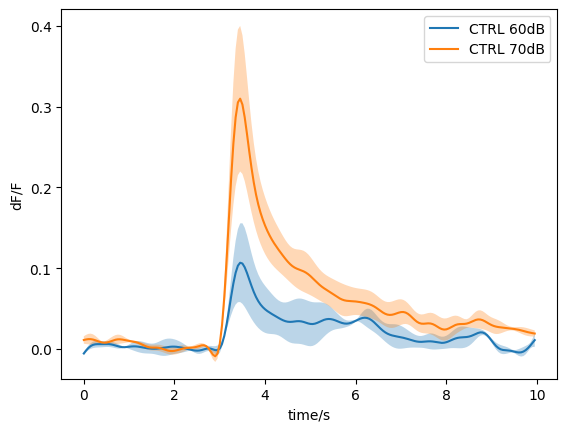

In [223]:
import matplotlib.pyplot as plt
import numpy as np
dB_lists = list(df_drop_drop['dB'].unique())

df_grouped = df_drop_drop.groupby(['dir', 'treatment', 'dB'], as_index=False)['dFF_ROI_linFilt_butterFilt'].mean()

df_avg=df_grouped.groupby(['treatment', 'dB'], as_index=False).agg(mean=('dFF_ROI_linFilt_butterFilt', 'mean'),std=('dFF_ROI_linFilt_butterFilt', lambda x:np.std(x.to_numpy(), ddof=1,axis=0)))
df_avg['se']=df_avg['std']/np.sqrt(len(dPaths))
df_avg['upper']=df_avg['mean']+df_avg['se']
df_avg['lower']=df_avg['mean']-df_avg['se']

plt.figure()
for (treatment,dB), group in df_avg.groupby(['treatment','dB']):
    x=np.arange(200)/20
    y=group['mean'].to_numpy()[0]

    plt.plot(x,y,label=treatment+' '+str(dB)+'dB')
    plt.fill_between(x,group['lower'].to_numpy()[0],group['upper'].to_numpy()[0],alpha=0.3)


plt.xlabel("time/s")
plt.ylabel("dF/F")
plt.legend()
plt.show()

In [11]:
# plot averaged traces for a given sound intensity re treatments and animals

import lib.plotting as plotting

# 80 dB, raw dFF trace, different treatments in separate subplots
plotting.plotTrace_reAnimal(df_drop_drop, dB_plot=60, resp_col='dFF_ROI_raw', sepPlot=True)

# 80 dB, raw dFF trace, different treatments in the same plot distinguished by color lightness
# plotting.plotTrace_reAnimal(df_drop_drop, dB_plot=80, resp_col='dFF_ROI_raw', sepPlot=False)

# 80 dB, processed dFF trace in separate subplots
# plotting.plotTrace_reAnimal(df_drop_drop, dB_plot=80, resp_col='dFF_ROI_linFilt_butterFilt', sepPlot=True)

# 80 dB, raw dF trace, different treatments in separate subplots
# plotting.plotTrace_reAnimal(df_drop_drop, dB_plot=80, resp_col='dF_ROI_raw', sepPlot=True)

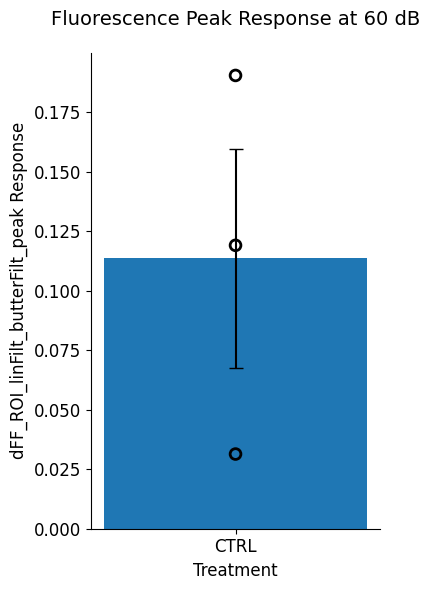

,treatment,dB,count,mean,std,sem
0,CTRL,60,3,0.113592,0.079648,0.045985


In [44]:
# plot barplots for a given sound intensity (eg. 80 dB) for pre- and post-ZX1 across animals
# show points indicating dFF peak response of each animal or each trial

import lib.plotting as plotting

# processed dFF peak response, not normalized, then averaged across animals
plotting.barplot_avgDFF_singleDB(df_drop_drop, dB_plot=60, resp_col="dFF_ROI_linFilt_butterFilt_peak", avgAnimal=True, normalize=None)

# processed dFF peak response, normalized the mean of each treament to the CTRL mean within each animal, then averaged across animals (suggested)
# plotting.barplot_avgDFF_singleDB(df_drop_drop, dB_plot=70, resp_col="dFF_ROI_linFilt_butterFilt_peak", avgAnimal=True, normalize='byGroup')

# processed dFF peak response, normalized to the trial with CTRL response within each animal, then averaged across animals
# plotting.barplot_avgDFF_singleDB(df_drop_drop, dB_plot=80, resp_col="dFF_ROI_linFilt_butterFilt_peak", avgAnimal=True, normalize='byTrial')

# processed dFF peak response, normalized to the trial with CTRL response within each animal, then averaged across all trials of all animals
# plotting.barplot_avgDFF_singleDB(df_drop_drop, dB_plot=80, resp_col="dFF_ROI_linFilt_butterFilt_peak", avgAnimal=False, normalize='byTrial')

# processed dFF peak response, normalized each trial to the CTRL mean within each animal, then averaged across all trials of all animals
# plotting.barplot_avgDFF_singleDB(df_drop_drop, dB_plot=80, resp_col="dFF_ROI_linFilt_butterFilt_peak", avgAnimal=False, normalize='trial2group')

# same for raw dFF peak response
# plotting.barplot_avgDFF_singleDB(df_drop_drop, dB_plot=80, resp_col='dFF_ROI_raw_peak', avgAnimal=True, normalize=None)
# plotting.barplot_avgDFF_singleDB(df_drop_drop, dB_plot=80, resp_col='dFF_ROI_raw_peak', avgAnimal=True, normalize='byGroup')
# plotting.barplot_avgDFF_singleDB(df_drop_drop, dB_plot=80, resp_col='dFF_ROI_raw_peak', avgAnimal=True, normalize='byTrial')

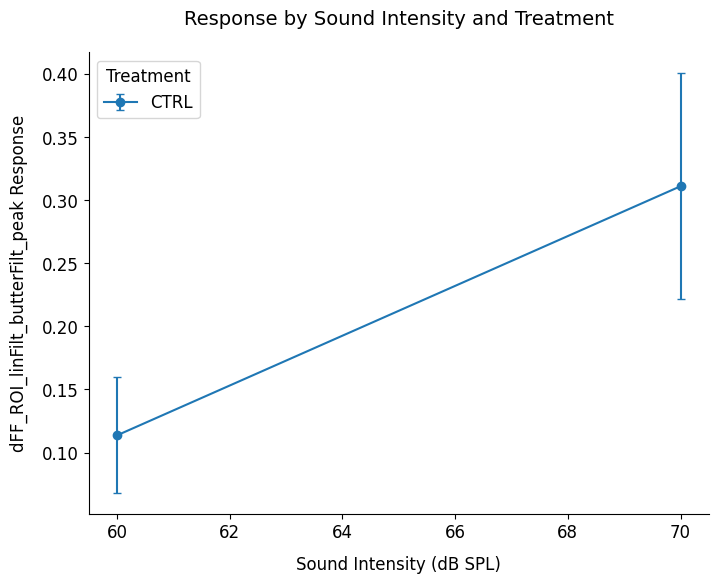

,treatment,dB,count_dFF_ROI_linFilt_butterFilt_peak,mean_dFF_ROI_linFilt_butterFilt_peak,std_dFF_ROI_linFilt_butterFilt_peak,sem_dFF_ROI_linFilt_butterFilt_peak
0,CTRL,60,3,0.113592,0.079648,0.045985
1,CTRL,70,3,0.311108,0.154938,0.089453


In [48]:
# plot lineplot or barplots averaged across animals or individual trials re sound intensities, pre- and post-ZX1, showing error bars
# create a new dataframe including the mean, SD, and SEM of peak response for each sound level

import lib.plotting as plotting

# Average across animals
# Lineplot
plotting.plot_avgDFF_acrossAnimal(df_drop_drop, measure_col='dB', resp_col="dFF_ROI_linFilt_butterFilt_peak", 
                                  avgAnimal=True, normalize=None, capsize=3)

# Normalize on group or individual trial basis
# plotting.plot_avgDFF_acrossAnimal(df_drop_drop, measure_col='dB', resp_col="dFF_ROI_linFilt_butterFilt_peak", 
#                                   avgAnimal=True, normalize='byGroup', capsize=3)
# plotting.plot_avgDFF_acrossAnimal(df_drop_drop, measure_col='dB', resp_col="dFF_ROI_linFilt_butterFilt_peak", 
#                                   avgAnimal=True, normalize='byTrial', capsize=3)
# plotting.plot_avgDFF_acrossAnimal(df_drop_drop, measure_col='dB', resp_col="dFF_ROI_linFilt_butterFilt_peak", 
#                                   avgAnimal=False, normalize='byTrial', capsize=3)

# Error bars represent standard deviation (SD) instead of standard error (SEM)
# plotting.plot_avgDFF_acrossAnimal(df_drop_drop, measure_col='dB', resp_col="dFF_ROI_linFilt_butterFilt_peak", 
#                                   avgAnimal=True, normalize=None, SEMbar=False, capsize=3)

# Average across individual trials
# plotting.plot_avgDFF_acrossAnimal(df_drop_drop, measure_col='dB', resp_col="dFF_ROI_linFilt_butterFilt_peak", 
#                                   avgAnimal=False, normalize=None, capsize=3)

# same for dF response
# plotting.plot_avgDFF_acrossAnimal(df_drop_drop, measure_col='dB', resp_col="dF_ROI_linFilt_butterFilt_peak", 
#                                   avgAnimal=True, normalize=None, capsize=3)

# Barplots
# plotting.plot_avgDFF_acrossAnimal(df_drop_drop, measure_col='dB', resp_col="dFF_ROI_linFilt_butterFilt_peak", 
#                                   avgAnimal=True, normalize=None, capsize=3, plotAvg_reLevel='bar')

C:\Users\JIC402\AppData\Local\Temp\ipykernel_6216\3215064324.py:30: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



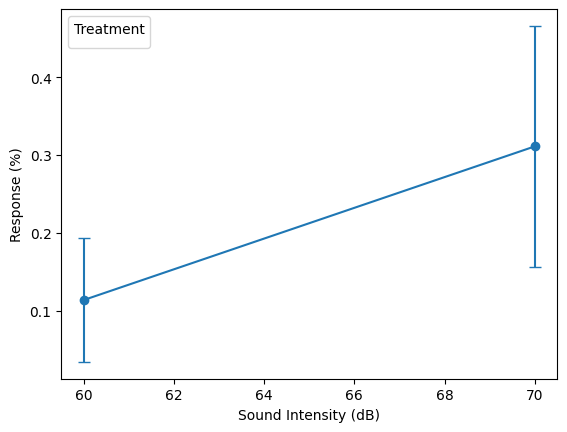

In [184]:
import matplotlib.pyplot as plt


dB_lists = list(df_drop_drop['dB'].unique())
# dB_lists = sorted(dB_lists)

df_grouped = df_drop_drop.groupby(['dir', 'treatment', 'dB'], as_index=False)['dFF_ROI_linFilt_butterFilt_peak'].mean()

# dB_lists = list(df_drop_drop.groupby(['dir', 'treatment'], sort=True)['dB'].unique())
# dB_lists

# common_dB = set(dB_lists[0])
# for item in dB_lists[1:]:    # Iterate over the remaining lists/Remove the items that is not present in both
#     common_dB.intersection_update(item)
# common_dB = sorted(common_dB)

# df_filtered = df_drop_drop[df_drop_drop['dB'].isin(common_dB)]

# df_grouped = df_filtered.groupby(['dir', 'treatment', 'dB'], as_index=False)['dFF_ROI_linFilt_butterFilt_peak'].mean()

df_avg=df_grouped.groupby(['treatment', 'dB'], as_index=False).agg(mean=('dFF_ROI_linFilt_butterFilt_peak', 'mean'), std=('dFF_ROI_linFilt_butterFilt_peak', 'std'))


plt.figure()
for treatment, group in df_avg.groupby('treatment'):

    plt.errorbar(group['dB'], group['mean'], yerr=group['std'],fmt='o-',capsize=4)
plt.xlabel("Sound Intensity (dB)")
plt.ylabel("Response (%)")
plt.legend(title="Treatment")
plt.show()

In [119]:
df_avg

,treatment,dB,mean,std
0,CTRL,60,0.113592,0.079648
1,CTRL,70,0.311108,0.154938


C:\Users\JIC402\AppData\Local\Temp\ipykernel_6216\1697731383.py:13: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



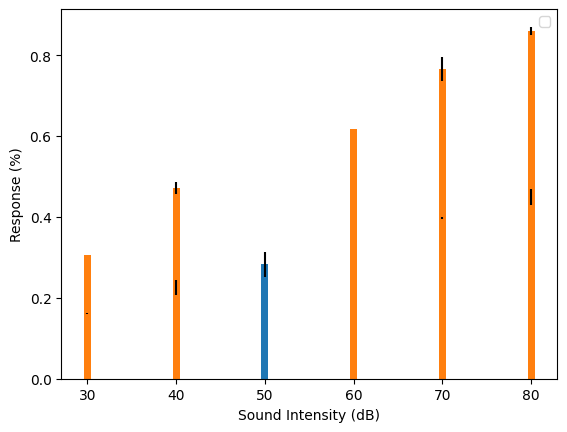

In [ ]:
dftest=pd.read_csv(r'c:\Users\JIC402\Desktop\testdata.csv')
dB_lists = list(dftest['dB'].unique())
dftest_grouped = dftest.groupby(['dir', 'treatment', 'dB'], as_index=False)['dFF'].mean()

dftest_avg=dftest_grouped.groupby(['treatment', 'dB'], as_index=False).agg(mean=('dFF', 'mean'), std=('dFF', 'std'))

plt.figure()

for treatment, group in dftest_avg.groupby('treatment'):
    plt.errorbar(group['dB'], group['mean'], yerr=group['std'],fmt='o-',capsize=4,label=treatment)
    

plt.bar(group['dB'], group['mean'], yerr=group['std'])

plt.xlabel("Sound Intensity (dB)")
plt.ylabel("Response (%)")
plt.legend()
plt.show()

In [113]:
dftest_avg

,treatment,dB,mean,std
0,1,30,0.160618,0.000835
1,1,40,0.225548,0.017970
2,1,50,0.282770,0.031756
3,1,70,0.398444,0.002435
4,1,80,0.449849,0.019389
5,2,30,0.306713,NaN
6,2,40,0.471485,0.013999
7,2,60,0.617198,NaN
8,2,70,0.766451,0.029719
9,2,80,0.859476,0.010780
